# Calculating neuron tuning to stim1 identity

Plan is to look at neuron firing rate during stim1 encoding period
- calculate whether there is a significant difference between fr when stim1 is +1 versus -1

In [1]:
import numpy as np 
import sys
from matplotlib import pyplot as plt
import matplotlib.patches as patches
import scipy
import os
import importlib
import pandas as pd

sys.path.append('/home/nuttidalab/Documents/spikeRNN/analysis/utils')
import load_data as ld 
import single_neuron_utils as sn 
from bootstrap_method import *



In [2]:
delay = 150
condn_phrase = 'delay'
condn_num = 150

# condn_key = f'{condn_phrase}{condn_num}'

In [3]:
# find folder names within model directory
all_models_dir = '/scratch/all_DMS_models/'

model_dirs = ld.get_immediate_subdirs(all_models_dir)
print(model_dirs)


['Task_xor_N_200_Taus_4.0_25.0_Act_sigmoid_2019_09_06_152659']


In [4]:
# choose model 0 to visualize for now
model_name = model_dirs[0]
model_dir = os.path.join(all_models_dir, model_name)

# find files for this delay of interest
data_files = ld.find_files_keywords(model_dir, [f'delay{delay}'])

## Scratch work / plotting for first time

In [ ]:
# neural data
importlib.reload(ld)
_, _, rates_data = ld.load_neural_data(model_name, condn_phrase, condn_num,
                                                  load_LFP=False, load_spikes=False, load_rates=True)
# behavioral data
trial_labels, trial_perfs = ld.load_bhv_data(model_name, condn_phrase='delay', condn_num=delay)

# timing data
_, times_real, fs_dict = ld.load_timing_data(model_name, condn_phrase='delay', condn_num=delay)
times_ms, _,_ = ld.get_times_dict('ds', condn_phrase, condn_num)


#### plot rates

In [6]:
rates_data.shape

(2055, 200, 1000)

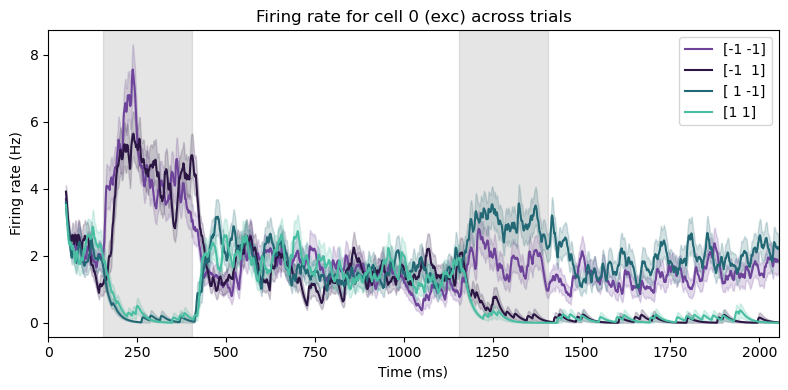

In [7]:
importlib.reload(sn)

sn.plot_neuron_rates(model_name, 0, condn_phrase, condn_num, cut_off=50)

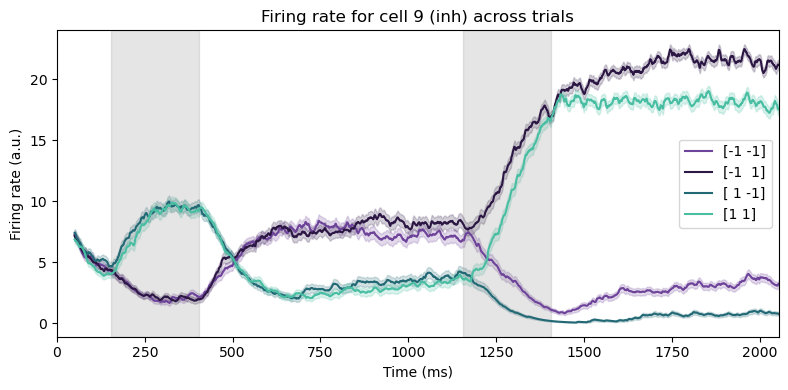

In [30]:
importlib.reload(sn)
sn.plot_neuron_rates(model_name, 9, condn_phrase, condn_num, cut_off=50)

In [10]:
# calculate all neuron tuning

all_stim1_fr = np.mean(rates_data[int(times_ms['stim1_on']):int(times_ms['stim1_off']), :,:], axis=0)
print(all_stim1_fr.shape)

(200, 1000)


In [30]:
# calculate tuning

trial_types, trial_idxs = np.unique(trial_labels[:,0], return_inverse=True) # only stim1
n_trial_types = len(trial_types)

tuning = np.zeros(all_stim1_fr.shape[0]) # tuning for each neuron
for n_neuron in range(all_stim1_fr.shape[0]):
    stim1_rates = np.zeros((n_trial_types, int(rates_data.shape[2]/n_trial_types)))
    for i, trial_type in enumerate(trial_types):
        trials_idx = (trial_idxs == i)
        stim1_rates[i,:] = all_stim1_fr[n_neuron, trials_idx]
    _, p = scipy.stats.mannwhitneyu(stim1_rates[0,:], stim1_rates[1,:])
    if p < 0.05:
        tuning[n_neuron] = trial_types[np.argmax([stim1_rates[0,:].mean(), stim1_rates[1,:].mean()])]
    else:
        tuning[n_neuron] = np.nan


In [31]:
print(tuning[0])
print(tuning[9])

-1.0
1.0


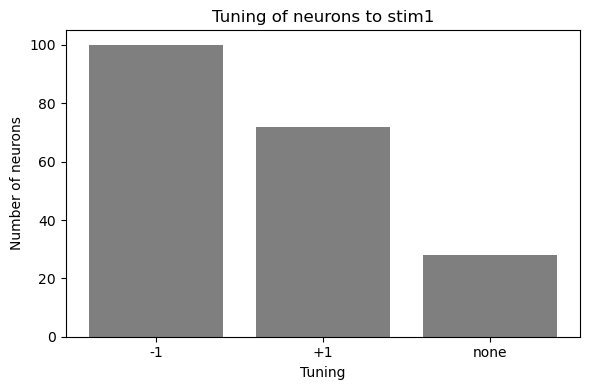

In [40]:
# plot bar graph of num neurons tuned to what

fig, ax = plt.subplots(figsize=(6,4))
x_labels = ['-1','+1','none']
x = np.arange(len(x_labels))
n_tuned = np.zeros(len(x_labels))
tuning_options = [-1, 1, np.nan]
for i, tuning_option in enumerate(tuning_options):
    n_tuned[i] = np.sum(tuning == tuning_option)
    if np.isnan(tuning_option):
        n_tuned[i] = np.sum(np.isnan(tuning))
ax.bar(x, n_tuned, color='black', alpha=0.5)
ax.set_xticks(x)
ax.set_xticklabels(x_labels)
ax.set_ylabel('Number of neurons')
ax.set_xlabel('Tuning')
ax.set_title('Tuning of neurons to stim1')
plt.tight_layout()
plt.show()


In [35]:
tuning.shape

(200,)

[80. 49. 26.]
[20. 23.  2.]


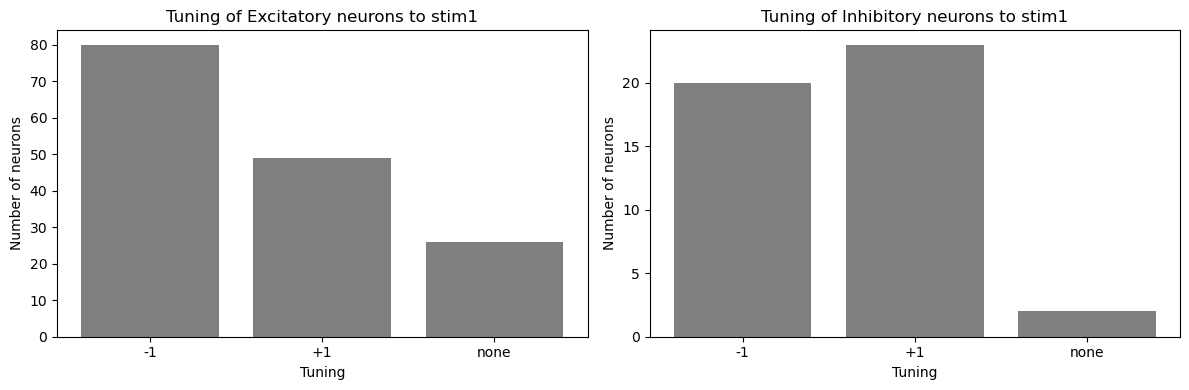

In [46]:
# split by exc/inh

# load exc/inh labels
exc_ind, inh_ind = ld.get_celltype_label(model_name)

# split tuning by exc/inh
fig, ax = plt.subplots(1,2,figsize=(12,4))
neur_type = ['Excitatory', 'Inhibitory']
for j, cell_type in enumerate([exc_ind, inh_ind]):
    x_labels = ['-1','+1','none']
    x = np.arange(len(x_labels))
    n_tuned = np.zeros(len(x_labels))
    tuning_options = [-1, 1, np.nan]
    for i, tuning_option in enumerate(tuning_options):
        n_tuned[i] = np.sum(tuning[cell_type] == tuning_option)
        if np.isnan(tuning_option):
            n_tuned[i] = np.sum(np.isnan(tuning[cell_type]))
    print(n_tuned)
    ax[j].bar(x, n_tuned, color='black', alpha=0.5)
    ax[j].set_xticks(x)
    ax[j].set_xticklabels(x_labels)
    ax[j].set_ylabel('Number of neurons')
    ax[j].set_xlabel('Tuning')
    ax[j].set_title(f'Tuning of {neur_type[j]} neurons to stim1')
plt.tight_layout()
plt.show()

## in one line function

In [5]:
# get tuning, one-line function

tuning = sn.calc_stim1_tuning(model_name, condn_phrase, condn_num)

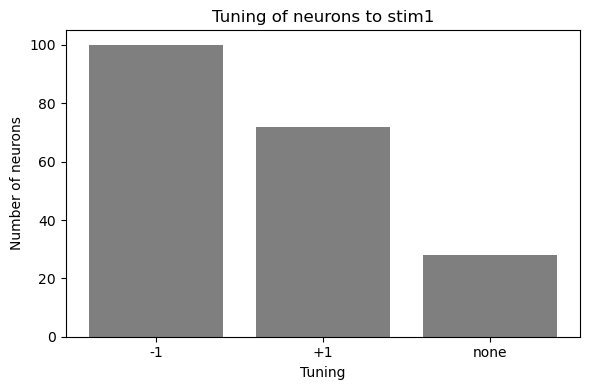

In [6]:
# plot bar graph of num neurons tuned to what

fig, ax = plt.subplots(figsize=(6,4))
x_labels = ['-1','+1','none']
x = np.arange(len(x_labels))
n_tuned = np.zeros(len(x_labels))
tuning_options = [-1, 1, np.nan]
for i, tuning_option in enumerate(tuning_options):
    n_tuned[i] = np.sum(tuning == tuning_option)
    if np.isnan(tuning_option):
        n_tuned[i] = np.sum(np.isnan(tuning))
ax.bar(x, n_tuned, color='black', alpha=0.5)
ax.set_xticks(x)
ax.set_xticklabels(x_labels)
ax.set_ylabel('Number of neurons')
ax.set_xlabel('Tuning')
ax.set_title('Tuning of neurons to stim1')
plt.tight_layout()
plt.show()


[80. 49. 26.]
[20. 23.  2.]


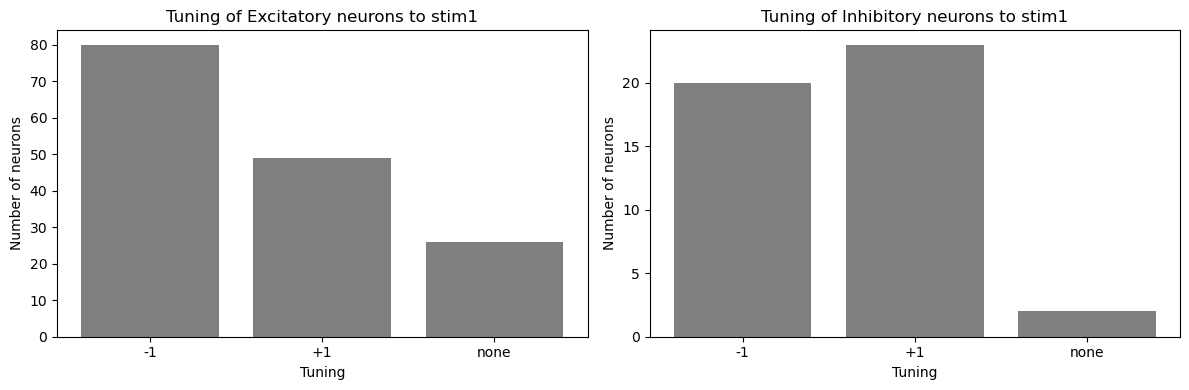

In [7]:
# split by exc/inh

# load exc/inh labels
exc_ind, inh_ind = ld.get_celltype_label(model_name)

# split tuning by exc/inh
fig, ax = plt.subplots(1,2,figsize=(12,4))
neur_type = ['Excitatory', 'Inhibitory']
for j, cell_type in enumerate([exc_ind, inh_ind]):
    x_labels = ['-1','+1','none']
    x = np.arange(len(x_labels))
    n_tuned = np.zeros(len(x_labels))
    tuning_options = [-1, 1, np.nan]
    for i, tuning_option in enumerate(tuning_options):
        n_tuned[i] = np.sum(tuning[cell_type] == tuning_option)
        if np.isnan(tuning_option):
            n_tuned[i] = np.sum(np.isnan(tuning[cell_type]))
    print(n_tuned)
    ax[j].bar(x, n_tuned, color='black', alpha=0.5)
    ax[j].set_xticks(x)
    ax[j].set_xticklabels(x_labels)
    ax[j].set_ylabel('Number of neurons')
    ax[j].set_xlabel('Tuning')
    ax[j].set_title(f'Tuning of {neur_type[j]} neurons to stim1')
plt.tight_layout()
plt.show()